# Notebook 08: Model Interpretation using SHAP
Goal: Understand which hand landmarks influence predictions


In [1]:
from pathlib import Path

# Get project root safely (works in Jupyter)
PROJECT_ROOT = Path.cwd().parent

print("Project root:", PROJECT_ROOT)


Project root: d:\Final year project-two hands


In [2]:
# Load trained MLP model and dataset (PATH-SAFE)

import shap
import pandas as pd
import numpy as np
import tensorflow as tf
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

data_path = PROJECT_ROOT / "data" / "processed" / "feature_engineered_keypoint.csv"
model_path = PROJECT_ROOT / "model_artifacts" / "keypoint_classifier" / "keypoint_classifier.hdf5"

# Verify paths
assert data_path.exists(), f"❌ Dataset not found: {data_path}"
assert model_path.exists(), f"❌ Model not found: {model_path}"

# Load data
df = pd.read_csv(data_path)
X = df.iloc[:, 1:].values
y = df["class"].values

# Load model
model = tf.keras.models.load_model(model_path)

print("✅ Dataset and model loaded successfully")


d:\Final year project-two hands\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Dataset and model loaded successfully


4/4 [==============================] - 0s 3ms/step


  0%|          | 0/20 [00:00<?, ?it/s]

6900/6900 [==============================] - 16s 2ms/step


  5%|▌         | 1/20 [00:20<06:28, 20.44s/it]

6900/6900 [==============================] - 15s 2ms/step


...

 90%|█████████ | 18/20 [06:18<00:34, 17.35s/it]

6900/6900 [==============================] - 15s 2ms/step


 95%|█████████▌| 19/20 [06:35<00:17, 17.44s/it]

6900/6900 [==============================] - 14s 2ms/step


100%|██████████| 20/20 [06:52<00:00, 20.62s/it]


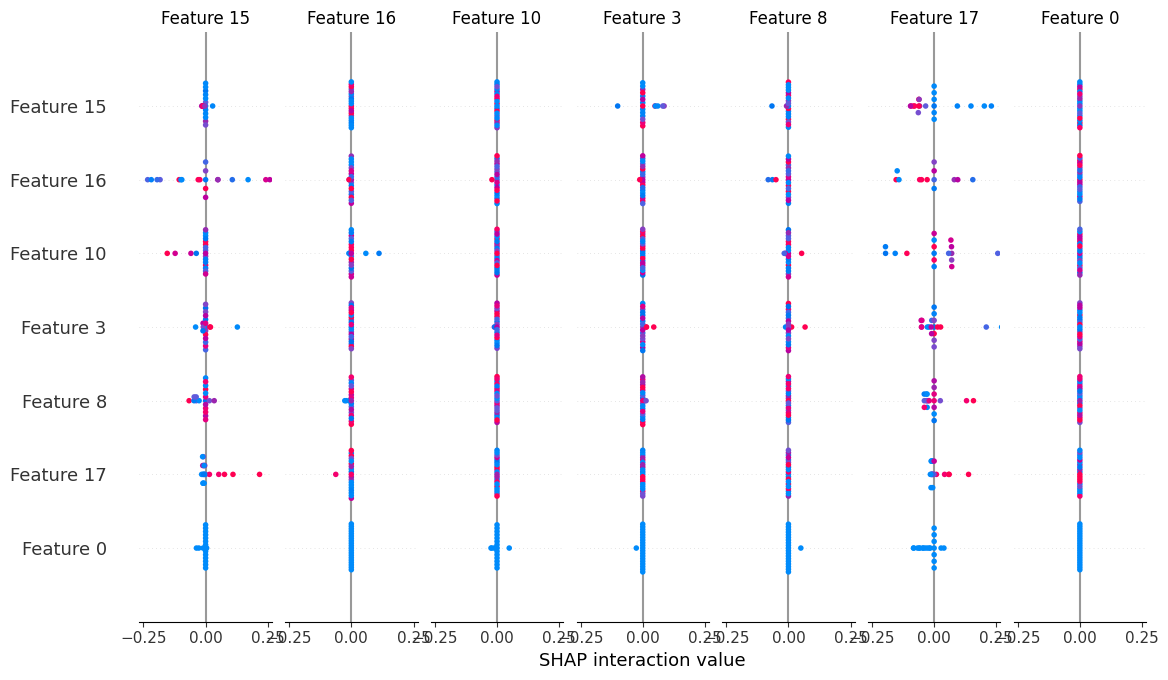

In [4]:
import shap
import numpy as np

# Use ONLY the 84 features used by the trained model
X_landmarks = X[:, :84]

# Background dataset (small for speed)
background = X_landmarks[
    np.random.choice(len(X_landmarks), 100, replace=False)
]

# Create SHAP explainer
explainer = shap.KernelExplainer(model.predict, background)

# Explain a few samples
sample = X_landmarks[:20]
shap_values = explainer.shap_values(sample)

# Visualization
shap.summary_plot(shap_values, sample)


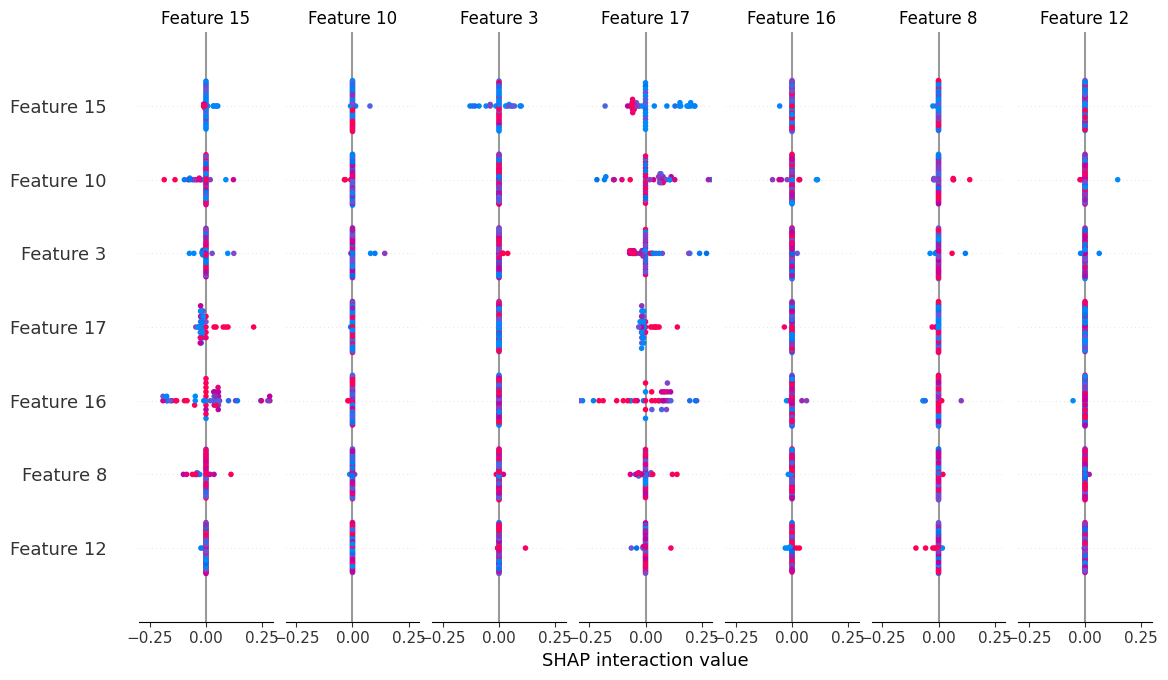

In [7]:
# Global feature importance
shap.summary_plot(shap_values, sample)
